# End-to-End Demo

Tutorial notebooks (`01`-`07`) build every component from scratch in-place. This notebook is the *showcase*: it imports the finished package from `src/transformer/` and runs the full pipeline end-to-end.

1. Load the Shakespeare corpus and build a char vocabulary
2. Instantiate the decoder-only transformer
3. Sample text from the untrained model (random baseline)
4. Train for 3000 steps with Adam
5. Plot the loss curve
6. Sample text at different temperatures
7. Visualize a learned attention head

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from transformer.data import load_corpus, split_data
from transformer.generate import generate
from transformer.model import Transformer
from transformer.train import TrainConfig, train

np.random.seed(42)
rng = np.random.default_rng(42)

## 1. Corpus and vocabulary

In [2]:
text, vocab, data = load_corpus('../data/input.txt')

print(f'Corpus length: {len(text):,} chars')
print(f'Vocab size:    {vocab.size}')
print(f'Characters:    {repr("".join(vocab.chars))}')

Corpus length: 10,160 chars
Vocab size:    58
Characters:    "\n !',-.:;?ABCDEFGHIJLMNOPRSTUVWYabcdefghijklmnopqrstuvwxyz"


## 2. Model

In [3]:
model = Transformer(
    vocab_size=vocab.size,
    d_model=64,
    n_heads=4,
    d_ff=256,
    n_layers=3,
    max_seq_len=32,
    dropout=0.1,
)
print(f'Parameters: {model.count_params():,}')

Parameters: 156,794


## 3. Sample before training

In [4]:
print(generate(model, vocab, start='First', max_new_tokens=120, temperature=1.0, rng=rng))

FirstpSriAyoqBUSuirVFbArfoOysqFW.DgkyLOVFCVFgSriJrqOIgDF
qgiqUbDAgVbnfbbI,SFPrF;IIfbqgPrD'AiUDWDiSOIfOAAxtiHyoiSHAtUFJbErniSf


## 4. Train

In [5]:
train_data, val_data = split_data(data, val_fraction=0.1)
config = TrainConfig(
    n_steps=3000, batch_size=32, seq_len=32, lr=1e-3,
    log_every=500, eval_every=500, eval_batches=20,
)
history = train(model, train_data, config, val_data=val_data, rng=rng)
losses = history.train_loss

step   500/3000 | loss 2.7324 | 48.7 steps/s
step   500/3000 | val_loss 2.3584


step  1000/3000 | loss 2.0870 | 48.3 steps/s
step  1000/3000 | val_loss 2.1487


step  1500/3000 | loss 1.7955 | 48.3 steps/s
step  1500/3000 | val_loss 2.1535


step  2000/3000 | loss 1.5563 | 48.3 steps/s
step  2000/3000 | val_loss 2.2438


step  2500/3000 | loss 1.3660 | 48.4 steps/s
step  2500/3000 | val_loss 2.3865


step  3000/3000 | loss 1.2057 | 48.2 steps/s
step  3000/3000 | val_loss 2.5432


## 5. Loss curve

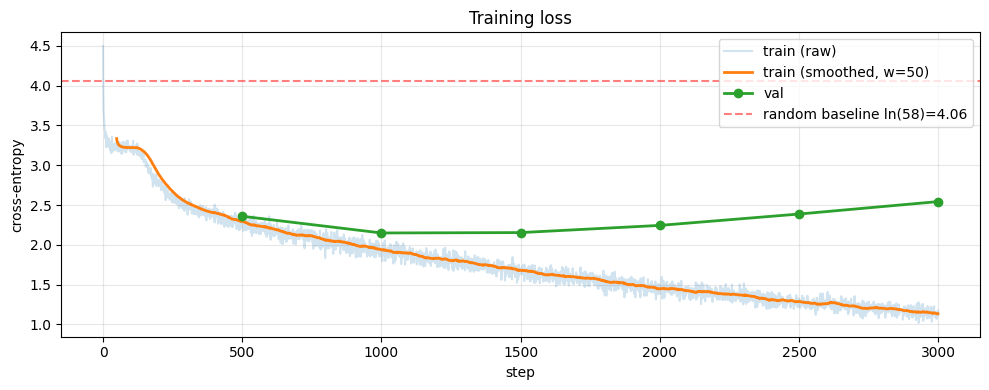

In [6]:
window = 50
smoothed = np.convolve(losses, np.ones(window) / window, mode='valid')

plt.figure(figsize=(10, 4))
plt.plot(losses, alpha=0.2, label='train (raw)')
plt.plot(range(window - 1, len(losses)), smoothed, linewidth=2, label=f'train (smoothed, w={window})')
if history.val_loss:
    val_steps, val_vals = zip(*history.val_loss)
    plt.plot(val_steps, val_vals, 'o-', linewidth=2, color='C2', label='val')
plt.axhline(np.log(vocab.size), color='red', linestyle='--', alpha=0.5, label=f'random baseline ln({vocab.size})={np.log(vocab.size):.2f}')
plt.xlabel('step')
plt.ylabel('cross-entropy')
plt.title('Training loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Sample after training

In [7]:
for temp in (0.3, 0.8, 1.2):
    print(f'--- temperature = {temp} ---')
    print(generate(model, vocab, start='First Citizen', max_new_tokens=200, temperature=temp, rng=rng))
    print()

--- temperature = 0.3 ---
First Citizen:
Well, well, well, sir, we are and the belly to calmonaly.

MENENIUS:
What then?

MENENIUS:
What who know't.

First Citizen:
I sir, well, and could you have done for our the body,
Will; and you do do

--- temperature = 0.8 ---


First Citizen:
Well, well, we as are swer: and though Roman alsher are acctions answer: how housald him reber, you do know
Would you curselves? The matter, who coulds of us to the poor in your belly,
And he vise c

--- temperature = 1.2 ---
First Citizen:
One side from this fenger should corvies.

First Citizen:
Consider your ime, 'Thane thon? ne way, this grainess elshembers
Re
Rebell, evir. Would you
A knd weceip of this dear, evis s.

First Citize



## 7. Learned attention head

Feed a short prompt through the trained model and inspect the attention weights from head 0 of block 0.

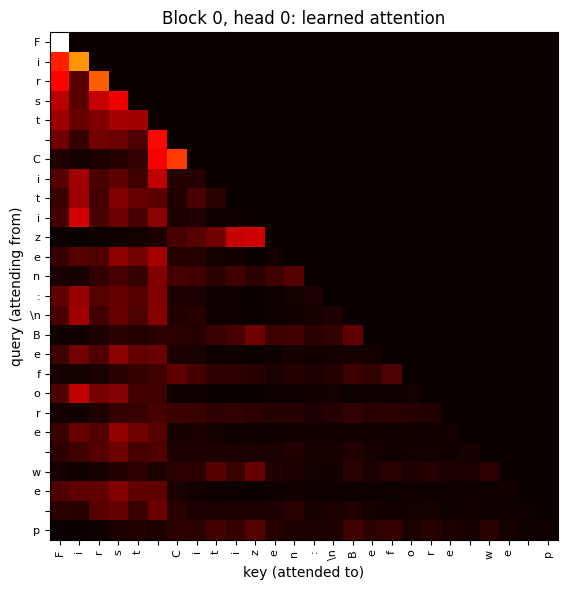

In [8]:
sample = 'First Citizen:\nBefore we p'
indices = np.array([vocab.encode(sample)])
_ = model.forward(indices)

attn = model.blocks[0].mha.attn_weights[0, 0]
tokens = [c if c != '\n' else '\\n' for c in sample]
T = len(tokens)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(attn[:T, :T], cmap='hot', vmin=0)
ax.set_xticks(range(T))
ax.set_xticklabels(tokens, fontsize=8, rotation=90)
ax.set_yticks(range(T))
ax.set_yticklabels(tokens, fontsize=8)
ax.set_xlabel('key (attended to)')
ax.set_ylabel('query (attending from)')
ax.set_title('Block 0, head 0: learned attention')
plt.tight_layout()
plt.show()